# WISDM Dataset 기반 LSTM 분류

## 결과 분석
Test accuracy:92.84%

WISDM 데이터셋을 LSTM 기반 모델로 학습한 결과 정확도는 92.84%로 나타났다.

LSTM은 gate와 cell state를 통해 중요한 시간 정보를 선택적으로 유지할 수 있기 때문에 SimpleRNN보다 높은 정확도를 기록하였다.

WISDM처럼 연속적인 움직임 패턴이 중요한 HAR 데이터에서는 LSTM이 RNN보다 시간 흐름을 더 안정적으로 학습할 수 있다.

따라서 WISDM 데이터셋에서는 LSTM은 SimpleRNN보다 WISDM 데이터셋에 더 적합하다고 판단된다.



In [ ]:
# Library imports
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity -> 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26
  - 27 ≤ user_id ≤ 31
  - user_id ≥ 32
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [ ]:
# raw 데이터 로드
# WISDM raw data는 컬럼명이 없는 형태
# 각 칼럼에 이름 지정
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";") # 세미콜론 이후 내용 무시
print(data.head())


   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [ ]:
# 클린업
# 문자열 값을 float32 숫자형으로 변환
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

# 앞에서 raw data를 읽을 때 생긴 불필요한 NaN 컬럼 제거
df = data.drop('NaN', axis=1)
# 결측값 행 제거
df = df.dropna()

# 세미콜론 제거
df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
# x, y, z축 가속도 값을 문자열에서 float32 숫자형으로 변환
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [ ]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))



Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [ ]:
# Data Split (user_id 기반)
# user_id가 26 이하 = train set
df_train = df[df['user_id'] <= 26]
# user_id가 27~31인 = validation set
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
# user_id가 32 이상 = test set
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")



Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [ ]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])


In [ ]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    # 전체 데이터를 time_steps 길이만큼 자르고 step 간격으로 이동
    for i in range(0, len(x) - time_steps, step):
        # 현재 window에 해당하는 x/y/z 센서 값 추출
        v = x.iloc[i:i + time_steps].values
        # 현재 window 안에 포함된 activity label 추출
        labels = y.iloc[i:i + time_steps]
        # window 내부에서 가장 많이 등장한 label을 대표 label로 사용
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [ ]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록 만드는 역할
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## LSTM Model
- Single LSTM model

In [ ]:
# LSTM input shape: (timesteps, features)
input_shape = (x_train.shape[1], x_train.shape[2])

# Number of activity classes
num_classes = 6

# Model definition
model = Sequential([
    Input(shape=input_shape),

    # First LSTM layer
    LSTM(256, return_sequences=True),

    # Second LSTM layer
    LSTM(128, return_sequences=False),

    # Dense classifier head
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 200, 256)       │       266,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,646 (1.83 MB)

 Trainable params: 480,646 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
callbacks = [
    ModelCheckpoint(
        "WISDM_HAR_LSTM_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.3046 - sparse_categorical_accuracy: 0.4804
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.57073, saving model to WISDM_HAR_LSTM_best.h5



Epoch 1: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 1.1649 - sparse_categorical_accuracy: 0.5456 - val_loss: 1.2871 - val_sparse_categorical_accuracy: 0.5707
Epoch 2/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0780 - sparse_categorical_accuracy: 0.6055
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.57073
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 1.3776 - sparse_categorical_accuracy: 0.4506 - val_loss: 1.6723 - val_sparse_categorical_accuracy: 0.2476
Epoch 3/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.4858 - sparse_categorical_accuracy: 0.3736
Epoch 3: val_sparse_categorical_accuracy improved from 0.57073 to 0.58854, saving model to WISDM_HAR_LSTM_best.h5



Epoch 3: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 1.3264 - sparse_categorical_accuracy: 0.4259 - val_loss: 1.4052 - val_sparse_categorical_accuracy: 0.5885
Epoch 4/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0078 - sparse_categorical_accuracy: 0.6049
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.58854
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.9078 - sparse_categorical_accuracy: 0.6371 - val_loss: 1.5230 - val_sparse_categorical_accuracy: 0.5854
Epoch 5/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7878 - sparse_categorical_accuracy: 0.6813
Epoch 5: val_sparse_categorical_accuracy improved from 0.58854 to 0.65415, saving model to WISDM_HAR_LSTM_best.h5



Epoch 5: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.7218 - sparse_categorical_accuracy: 0.7063 - val_loss: 1.4857 - val_sparse_categorical_accuracy: 0.6541
Epoch 6/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6906 - sparse_categorical_accuracy: 0.7381
Epoch 6: val_sparse_categorical_accuracy improved from 0.65415 to 0.65927, saving model to WISDM_HAR_LSTM_best.h5



Epoch 6: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.7071 - sparse_categorical_accuracy: 0.7203 - val_loss: 1.4765 - val_sparse_categorical_accuracy: 0.6593
Epoch 7/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6350 - sparse_categorical_accuracy: 0.7594
Epoch 7: val_sparse_categorical_accuracy did not improve from 0.65927
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.6189 - sparse_categorical_accuracy: 0.7690 - val_loss: 1.5145 - val_sparse_categorical_accuracy: 0.5827
Epoch 8/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5626 - sparse_categorical_accuracy: 0.7733
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.65927
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.5347 - sparse_categorical_accuracy: 0.7999 - val_loss: 1.7573 - val_sparse_categorical_accuracy: 0.6129
Epoch 9/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4679 - sparse_categorical_accuracy: 0.8283
Epoch 9: val

...


Epoch 15: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.6634 - sparse_categorical_accuracy: 0.7441 - val_loss: 1.3207 - val_sparse_categorical_accuracy: 0.7644
Epoch 16/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3235 - sparse_categorical_accuracy: 0.8837
Epoch 16: val_sparse_categorical_accuracy did not improve from 0.76439
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.3075 - sparse_categorical_accuracy: 0.8887 - val_loss: 1.5433 - val_sparse_categorical_accuracy: 0.5434
Epoch 17/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3134 - sparse_categorical_accuracy: 0.8827
Epoch 17: val_sparse_categorical_accuracy did not improve from 0.76439
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.2760 - sparse_categorical_accuracy: 0.9056 - val_loss: 1.4754 - val_sparse_categorical_accuracy: 0.7359
Epoch 18/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2177 - sparse_categorical_accuracy: 0.9258
Epoch 


Epoch 20: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.1550 - sparse_categorical_accuracy: 0.9544 - val_loss: 1.0477 - val_sparse_categorical_accuracy: 0.7885
Epoch 21/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1193 - sparse_categorical_accuracy: 0.9657
Epoch 21: val_sparse_categorical_accuracy did not improve from 0.78854
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.1212 - sparse_categorical_accuracy: 0.9654 - val_loss: 1.5284 - val_sparse_categorical_accuracy: 0.7666
Epoch 22/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1465 - sparse_categorical_accuracy: 0.9597
Epoch 22: val_sparse_categorical_accuracy did not improve from 0.78854
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.1379 - sparse_categorical_accuracy: 0.9631 - val_loss: 1.6241 - val_sparse_categorical_accuracy: 0.7668
Epoch 23/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1036 - sparse_categorical_accuracy: 0.9714
Epoch 2


Epoch 28: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.0715 - sparse_categorical_accuracy: 0.9811 - val_loss: 1.5542 - val_sparse_categorical_accuracy: 0.7956
Epoch 29/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0715 - sparse_categorical_accuracy: 0.9795
Epoch 29: val_sparse_categorical_accuracy did not improve from 0.79561
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0906 - sparse_categorical_accuracy: 0.9737 - val_loss: 1.8614 - val_sparse_categorical_accuracy: 0.7346
Epoch 30/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1177 - sparse_categorical_accuracy: 0.9726
Epoch 30: val_sparse_categorical_accuracy improved from 0.79561 to 0.81439, saving model to WISDM_HAR_LSTM_best.h5



Epoch 30: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0864 - sparse_categorical_accuracy: 0.9789 - val_loss: 1.3198 - val_sparse_categorical_accuracy: 0.8144
Epoch 31/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0645 - sparse_categorical_accuracy: 0.9840
Epoch 31: val_sparse_categorical_accuracy did not improve from 0.81439
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0615 - sparse_categorical_accuracy: 0.9843 - val_loss: 1.7331 - val_sparse_categorical_accuracy: 0.7873
Epoch 32/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0760 - sparse_categorical_accuracy: 0.9806
Epoch 32: val_sparse_categorical_accuracy did not improve from 0.81439
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0602 - sparse_categorical_accuracy: 0.9849 - val_loss: 1.7558 - val_sparse_categorical_accuracy: 0.7980
Epoch 33/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0448 - sparse_categorical_accuracy: 0.9883
Epoch 


Epoch 38: finished saving model to WISDM_HAR_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0628 - sparse_categorical_accuracy: 0.9858 - val_loss: 0.7485 - val_sparse_categorical_accuracy: 0.8737
Epoch 39/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0463 - sparse_categorical_accuracy: 0.9883
Epoch 39: val_sparse_categorical_accuracy did not improve from 0.87366
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0490 - sparse_categorical_accuracy: 0.9874 - val_loss: 1.3824 - val_sparse_categorical_accuracy: 0.7983
Epoch 40/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0385 - sparse_categorical_accuracy: 0.9895
Epoch 40: val_sparse_categorical_accuracy did not improve from 0.87366
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0368 - sparse_categorical_accuracy: 0.9894 - val_loss: 0.8591 - val_sparse_categorical_accuracy: 0.8346
Epoch 41/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0267 - sparse_categorical_accuracy: 0.9922
Epoch 4

In [ ]:
# Model evaluation
model = tf.keras.models.load_model("WISDM_HAR_LSTM_best.h5")

train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.26%
Training loss: 0.0204
Test accuracy: 92.84%
Test loss: 0.4255


In [ ]:
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

  Downstairs       0.76      0.92      0.83       346
     Jogging       0.99      0.92      0.96      1316
     Sitting       1.00      1.00      1.00       300
    Standing       0.92      1.00      0.96       189
    Upstairs       0.82      0.72      0.77       384
     Walking       0.93      0.97      0.95      1350

    accuracy                           0.93      3885
   macro avg       0.91      0.92      0.91      3885
weighted avg       0.93      0.93      0.93      3885



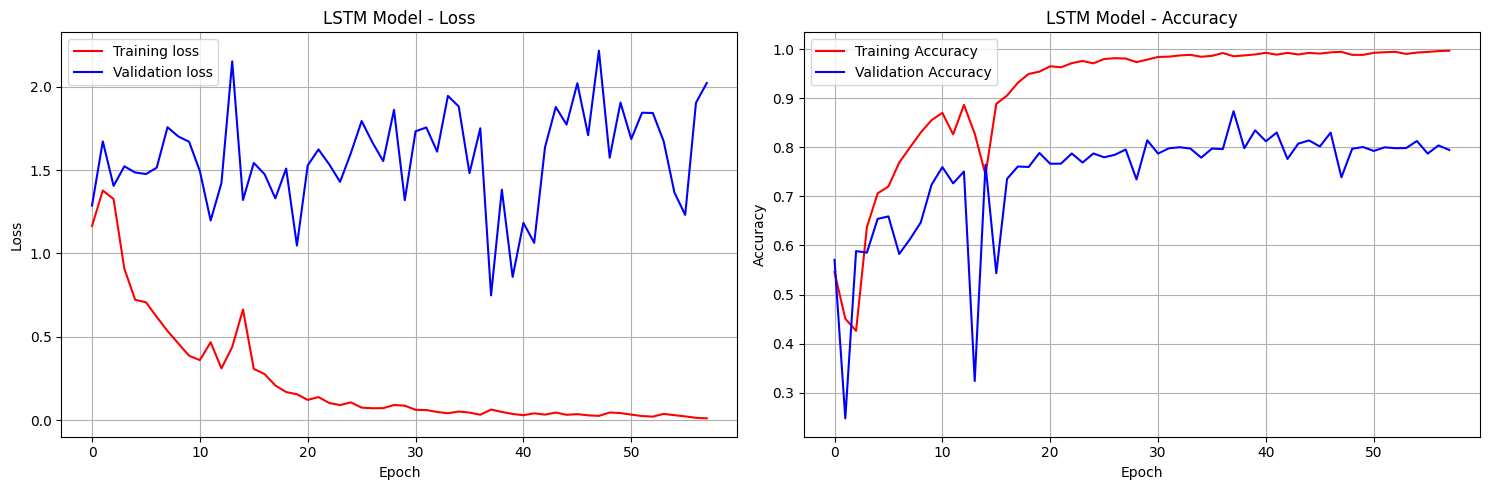

In [ ]:
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('LSTM Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('LSTM Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

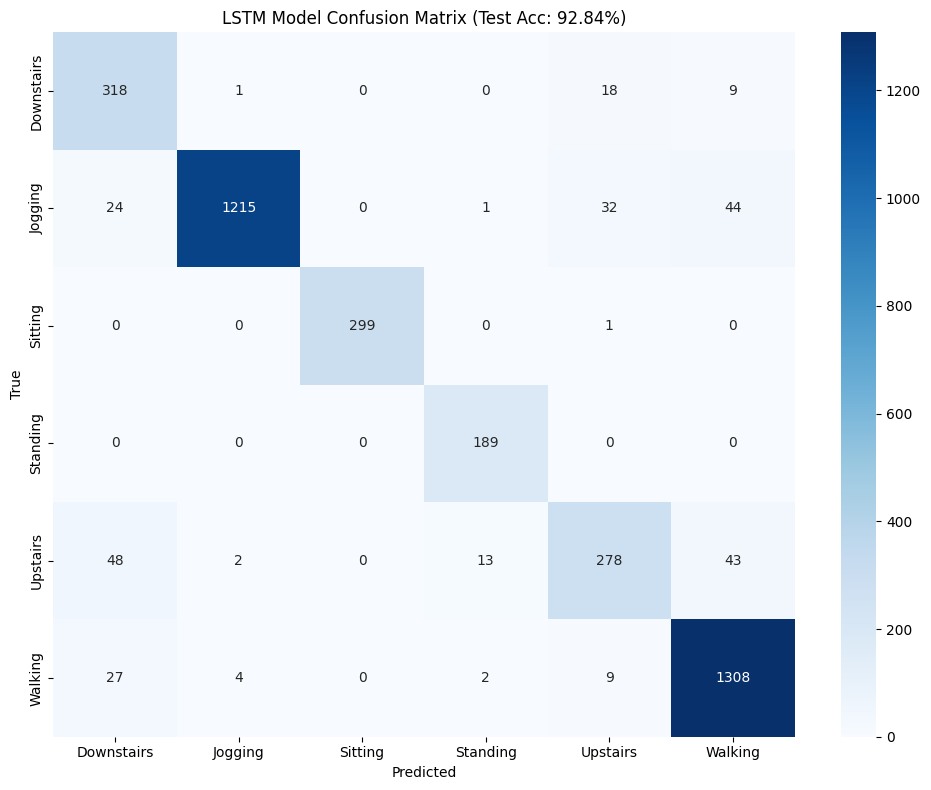

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'LSTM Model Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()